# Machine Learning Group Assginment

## Index
1. Import relvant libraries
2. Data Loading
3. Exploratory Data Analysis
    - Null Values Management
    - Distribution of Variables (Numerical and Categorical)
    - Outlier Management
4. Feature Engeneering
5. Correlation Analysis
6. Feature Selection
    - Clusering and Profiling Variables
7. Clustering Analsysis
    - Number of Cluster selection
    - K means algorythm
    - Cluster Profiling
    - Technical Evaluation
8. Regression:
    - Objective
    - Training
    - Validating
    - Testing
    

# 1. Import relevant labraries

In [30]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import  StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Lasso
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn import metrics


# 2. Data Loading 

In [31]:
df = pd.read_excel('Houses for rent in Madrid.xlsx')
df.head()

,Id,District,Address,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,1,Ciudad Lineal,Piso en Quintana,NaN,Quintana,1300,2.0,72,3.0,1.0,1.0,0,0,0,0
1,2,Ciudad Lineal,Piso en calle de Arturo Soria,NaN,Costillares,3000,5.0,260,2.0,1.0,1.0,0,0,0,0
2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,4,Colina,1300,2.0,100,3.0,1.0,1.0,0,0,0,0
3,4,Ciudad Lineal,Piso en calle Badajoz,NaN,San Pascual,1600,3.0,120,4.0,1.0,1.0,0,0,0,0
4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,9,Ventas,800,2.0,60,3.0,1.0,0.0,0,0,0,0


# 3. Exploratory Data Analysis

### Data Cleaning: drop NA values

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2089 entries, 0 to 2088
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2089 non-null   int64  
 1   District      2089 non-null   str    
 2   Address       2089 non-null   str    
 3   Number        747 non-null    str    
 4   Area          2085 non-null   str    
 5   Rent          2089 non-null   int64  
 6   Bedrooms      2000 non-null   float64
 7   Sq.Mt         2089 non-null   int64  
 8   Floor         1948 non-null   float64
 9   Outer         1927 non-null   float64
 10  Elevator      1956 non-null   float64
 11  Penthouse     2089 non-null   int64  
 12  Cottage       2089 non-null   int64  
 13  Duplex        2089 non-null   int64  
 14  Semidetached  2089 non-null   int64  
dtypes: float64(4), int64(7), str(4)
memory usage: 341.9 KB


Null Values Management

In [33]:
df.isna().sum()/df.shape[0]

Id              0.000000
District        0.000000
Address         0.000000
Number          0.642413
Area            0.001915
Rent            0.000000
Bedrooms        0.042604
Sq.Mt           0.000000
Floor           0.067496
Outer           0.077549
Elevator        0.063667
Penthouse       0.000000
Cottage         0.000000
Duplex          0.000000
Semidetached    0.000000
dtype: float64

Large amount of NaN in the Number column (64%), is not adding any information will be removed.
The other columns that have null values are binary variables, is does not make any sense to input a value and consdering that is only between 6-7% of the total observations those obserations with null values will be removed from the base

In [ ]:
df_notnull = df.drop(columns=['Number','Id','Address','Area'])
df_notnull.dropna(inplace=True)
df_notnull.isna().sum()

Id              0
District        0
Address         0
Area            0
Rent            0
Bedrooms        0
Sq.Mt           0
Floor           0
Outer           0
Elevator        0
Penthouse       0
Cottage         0
Duplex          0
Semidetached    0
dtype: int64

### EDA:
Distribution of Variables:
- The Address columns will not be explored beacuse it does not include relevant infromation.
- The Id column will be removed

In [ ]:
numeric_cols = ['Rent','Bedrooms','Sq.Mt','Floor']
binary_cols = ['Outer','Elevator','Penthouse','Cottage','Duplex','Semidetached']
categorical_cols =  ['District']

Numeric Columns Analsysis: 

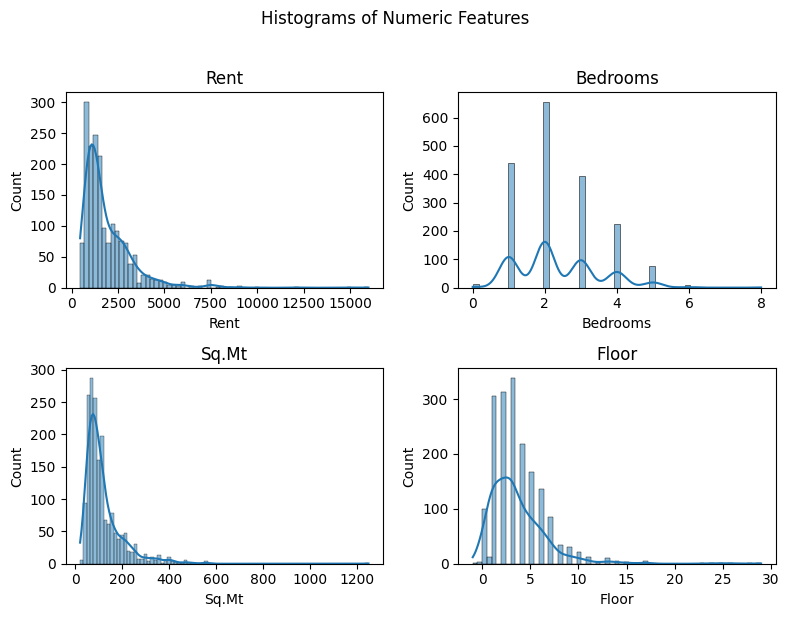

In [ ]:
n_num = len(numeric_cols)
if n_num:
    n_cols = 2
    n_rows = int(np.ceil(n_num / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        sns.histplot(df_notnull[col], kde=True, ax=ax, color="#1f77b4")
        ax.set_title(col)
    # Hide extra axes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    fig.suptitle('Histograms of Numeric Features', y=1.02)
    plt.tight_layout()
    plt.show()

Binary Columns Analsysis:

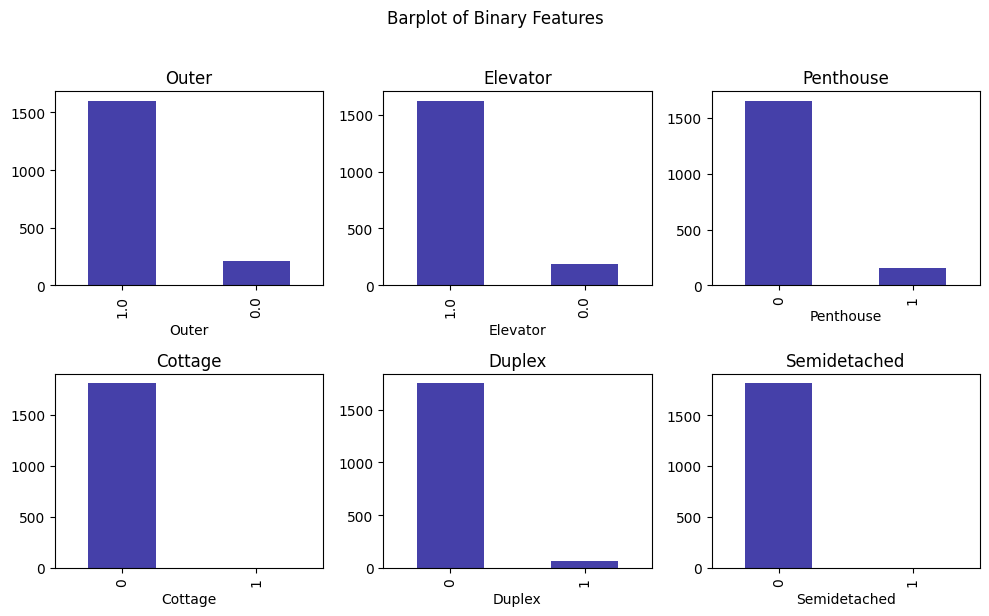

In [38]:
n_num = len(binary_cols)

if n_num:
    # fig, axes = plt.subplots(2, 3, figsize=(4*n_cols, 3*n_rows))
    # axes = axes.flatten()
    # for i, col in enumerate(binary_cols):
    #     ax = axes[i]
    #     sns.barplot(df_notnull[col], ax=ax, color="#1f77b4")
    #     ax.set_title(col)
    #  # Hide extra axes
    # for j in range(i+1, len(axes)):
    #     axes[j].axis('off')
    # fig.suptitle('Barplot of Binary Features', y=1.02)
    # plt.tight_layout()
    # plt.show()
    fig, axes = plt.subplots(2, 3, figsize=(20,12))
    axes = axes.flatten()
    for i,col in enumerate(binary_cols):
        ax = axes[i]
        vc = df_notnull[col].value_counts()
        vc.plot(kind='bar', figsize=(10,6), color="#4540a9",ax=ax)
        ax.set_title(f'{col}')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    fig.suptitle('Barplot of Binary Features', y=1.02)
    plt.tight_layout()
    plt.show()
  

In [39]:
df_notnull['Cottage'].value_counts()

Cottage
0    1812
1       3
Name: count, dtype: int64

In [40]:
df_notnull['Semidetached'].value_counts()

Semidetached
0    1813
1       2
Name: count, dtype: int64

From the count we can conclude that this two columns actually identify some apartments that have very specific caracteristics, so the columns will not be considered as part of the segmentation. 

Categorical Variables:

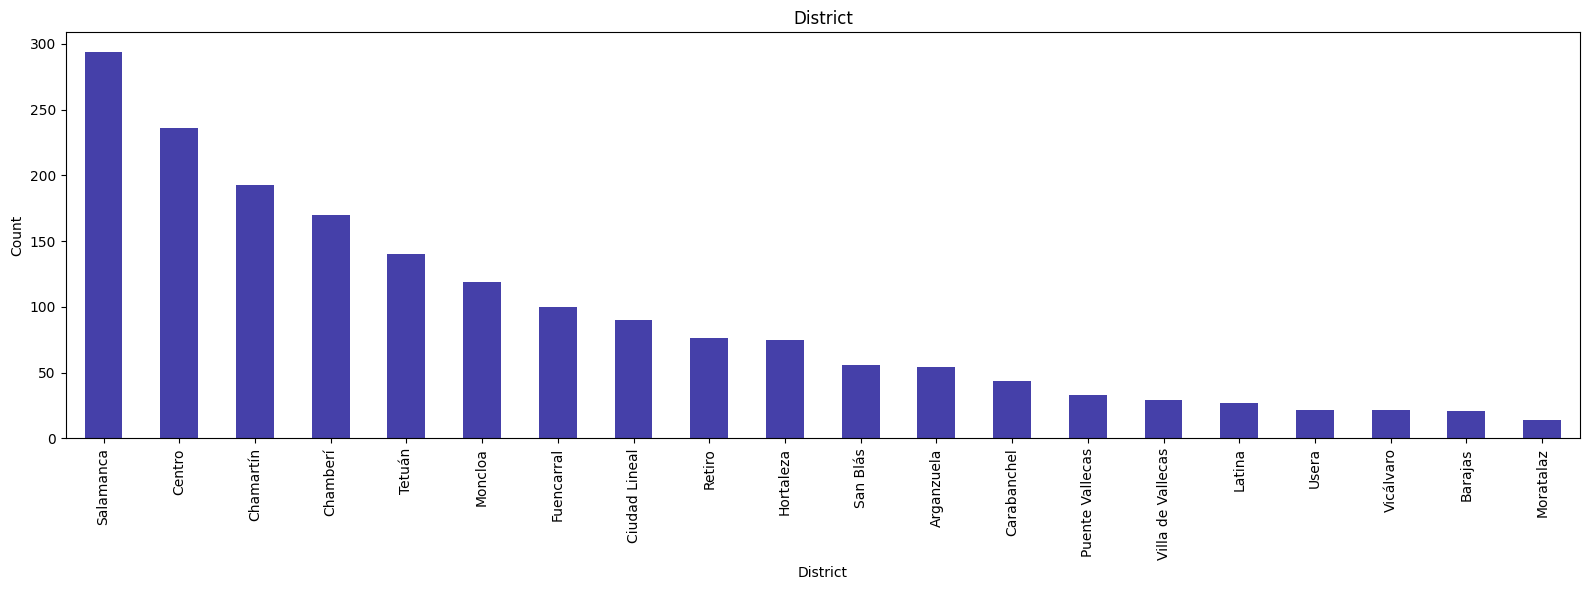

C:\Users\ricar\AppData\Local\Temp\ipykernel_16968\1008061276.py:8: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ricar\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


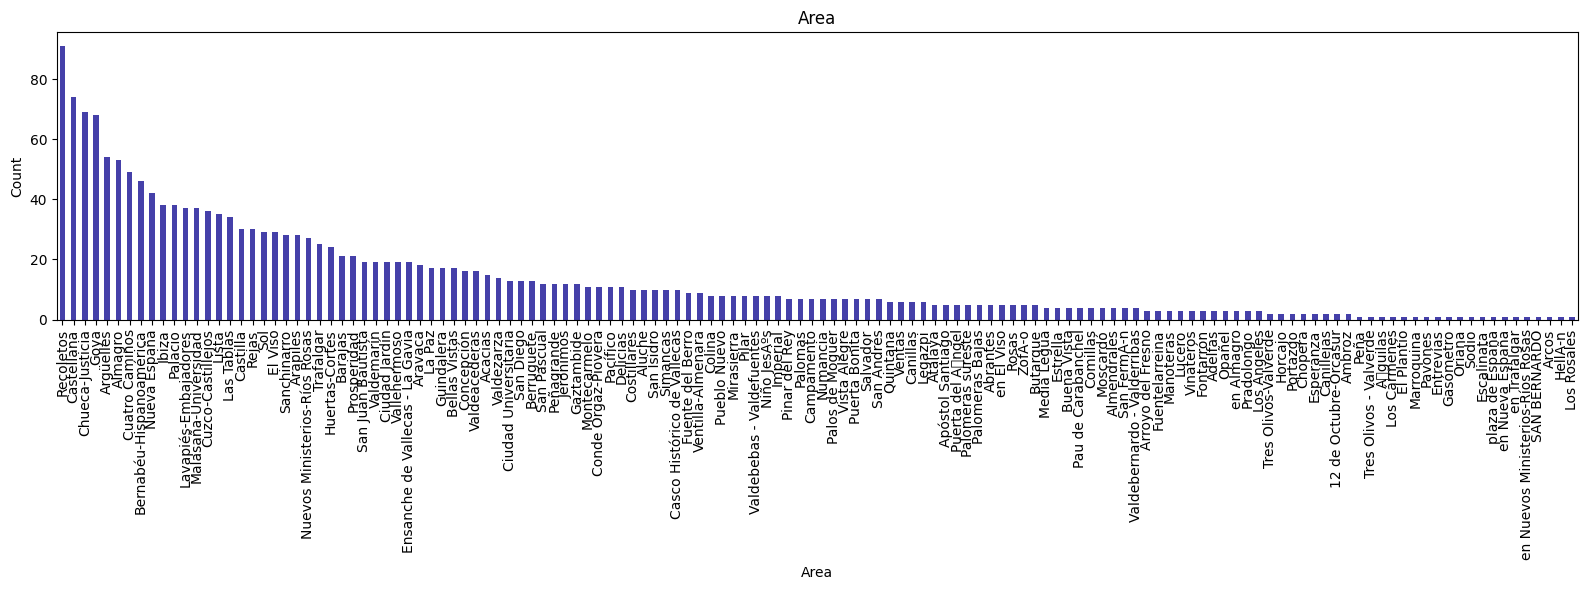

In [41]:
n_num = len(categorical_cols)
if n_num:
    for col in categorical_cols:
        vc = df_notnull[col].value_counts()
        ax = vc.plot(kind='bar', figsize=(16,6), color="#4540a9")
        ax.set_title(f'{col}')
        ax.set_ylabel('Count')
        plt.tight_layout()
        plt.show()
  

To simplify the analisis we will consder the district varibale that is a kind of aggrupation of the area variable that has a serveral of values that are not standarized 

### Outlier Identification 

From the hisogram of the floor variables is very evident that there is one or more outliers, to further investigate this we make boxplots for each variable

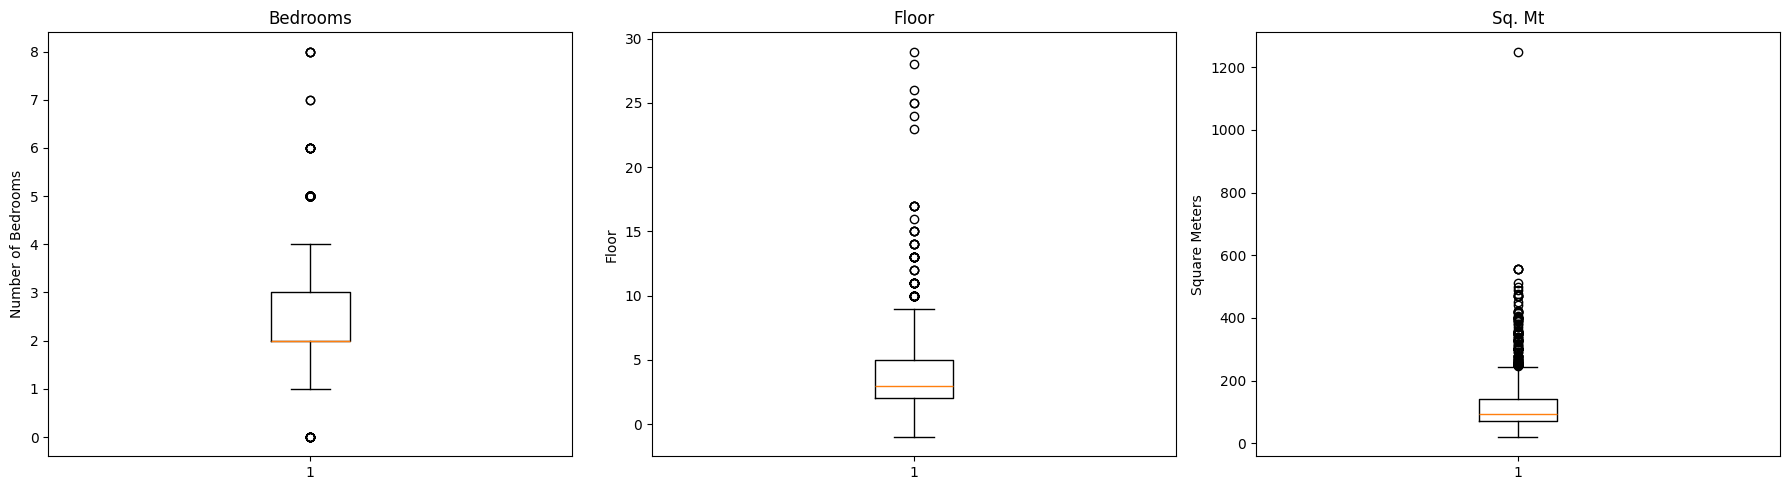

In [43]:
plt.figure(figsize=(18,5))

plt.subplot(1, 3, 1)
plt.boxplot(df_notnull["Bedrooms"].dropna())
plt.title("Bedrooms")
plt.ylabel("Number of Bedrooms")

plt.subplot(1, 3, 2)
plt.boxplot(df_notnull["Floor"].dropna())
plt.title("Floor")
plt.ylabel("Floor")

plt.subplot(1, 3, 3)
plt.boxplot(df_notnull["Sq.Mt"].dropna()) 
plt.title("Sq. Mt")
plt.ylabel("Square Meters")

plt.tight_layout()
plt.show()

In [44]:
df_notnull.describe().T

,count,mean,std,min,25%,50%,75%,max
Rent,1815.0,1882.716253,1356.953955,450.0,990.0,1400.0,2430.0,16000.0
Bedrooms,1815.0,2.371901,1.183767,0.0,2.0,2.0,3.0,8.0
Sq.Mt,1815.0,118.990634,83.044889,20.0,70.0,92.0,140.0,1250.0
Floor,1815.0,3.616529,3.008817,-1.0,2.0,3.0,5.0,29.0
Outer,1815.0,0.883196,0.321276,0.0,1.0,1.0,1.0,1.0
Elevator,1815.0,0.895317,0.306229,0.0,1.0,1.0,1.0,1.0
Penthouse,1815.0,0.087603,0.282795,0.0,0.0,0.0,0.0,1.0
Cottage,1815.0,0.001653,0.040633,0.0,0.0,0.0,0.0,1.0
Duplex,1815.0,0.034160,0.181690,0.0,0.0,0.0,0.0,1.0
Semidetached,1815.0,0.001102,0.033186,0.0,0.0,0.0,0.0,1.0


Now after removing the Nulls and looking closely at what look like outliers, we dont need to remove other observations, all values seem reasonable.

### Correlation Analysis

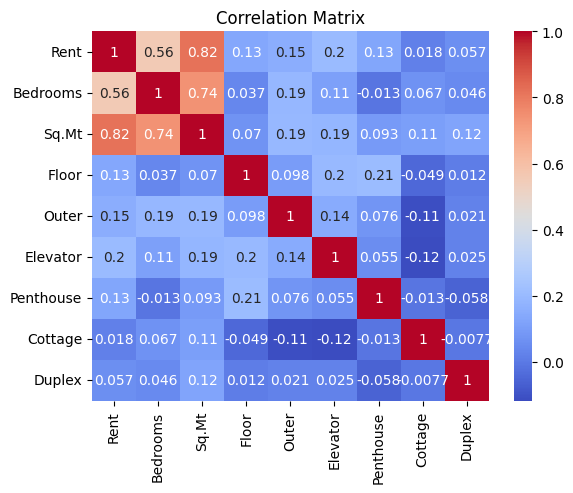

In [ ]:
corr = df_notnull[['Rent','Bedrooms','Sq.Mt','Floor','Outer','Elevator','Penthouse','Cottage','Duplex']].corr()

sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 4. Feature Engeneering:

For the model we One-hot encode the district variable

In [47]:
df_light = pd.get_dummies(df_notnull, drop_first=True).astype(int).copy()
df_light.head()

,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,...,District_Moncloa,District_Moratalaz,District_Puente Vallecas,District_Retiro,District_Salamanca,District_San Blás,District_Tetuán,District_Usera,District_Vicálvaro,District_Villa de Vallecas
0,1300,2,72,3,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3000,5,260,2,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1300,2,100,3,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1600,3,120,4,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,800,2,60,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 6. Feature Selection

Remove the predicted variables so the segmetns do not depend on the predicted variable

In [146]:
removed = ['Rent', 'Outer', 'Cottage', 'Duplex', 'Semidetached', 'District_Barajas',
       'District_Carabanchel', 'District_Centro', 'District_Chamartín',
       'District_Chamberí', 'District_Ciudad Lineal', 'District_Fuencarral',
       'District_Hortaleza', 'District_Latina', 'District_Moncloa',
       'District_Moratalaz', 'District_Puente Vallecas', 'District_Retiro',
       'District_Salamanca', 'District_San Blás', 'District_Tetuán',
       'District_Usera', 'District_Vicálvaro', 'District_Villa de Vallecas']
not_mask  = df_light.columns.isin(removed)
mask = [not x for x in not_mask]
features = df_light.columns[mask]
features

Index(['Bedrooms', 'Sq.Mt', 'Floor', 'Elevator', 'Penthouse'], dtype='str')

### Scaled Variables

# 8. Regression

Train, Validation and Test split

In [ ]:
train_size = 0.3
test_size = 1- train_size 

# Separate features and target
X = df_light.drop(columns=["Rent"])
y = df_light["Rent"]
# 70% train, 30% validation and test
X_train_c0, X_vt_c0, y_train_c0, y_vt_c0 = train_test_split(
X, y, test_size=0.30, random_state=42)
# Split temp into 15% val, 15% test
X_val_c0, X_test_c0, y_val_c0, y_test_c0 = train_test_split(X_vt_c0, y_vt_c0, test_size=0.50, random_state=42)

X_train_c0.shape, X_val_c0.shape, X_test_c0.shape

((1031, 28), (221, 28), (222, 28))

Variance Inflation Factor (VIF)

In [156]:
def remove_vif(df, thresh=10.0):
    df_actual = df.copy()

    while True:
        vif_data = pd.DataFrame()
        vif_data["Variable"] = df_actual.columns
        vif_data["VIF"] = [variance_inflation_factor(df_actual.values, i) 
                           for i in range(df_actual.shape[1])]
        
        max_vif = vif_data["VIF"].max()
        
        if max_vif > thresh:
            variable_to_remove = vif_data.sort_values("VIF", ascending=False).iloc[0]["Variable"]
            print(f"Removing '{variable_to_remove}' with VIF: {max_vif:.2f}")
            df_actual = df_actual.drop(columns=[variable_to_remove])
        else:
            break
            
    return df_actual

X_aftervif_c0 = remove_vif(X_train_c0, thresh=10.0)

print("\nFinal set of variables:")
print(X_aftervif_c0.columns.tolist())

c:\Users\ricar\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\ricar\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


Removing 'Elevator' with VIF: 46.04
Removing 'Bedrooms' with VIF: 12.47

Final set of variables:
['Sq.Mt', 'Floor', 'Outer', 'Penthouse', 'Cottage', 'Duplex', 'Semidetached', 'District_Barajas', 'District_Carabanchel', 'District_Centro', 'District_Chamartín', 'District_Chamberí', 'District_Ciudad Lineal', 'District_Fuencarral', 'District_Hortaleza', 'District_Latina', 'District_Moncloa', 'District_Moratalaz', 'District_Puente Vallecas', 'District_Retiro', 'District_Salamanca', 'District_San Blás', 'District_Tetuán', 'District_Usera', 'District_Vicálvaro', 'District_Villa de Vallecas']


c:\Users\ricar\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


In [157]:
base_model = LinearRegression()

rfecv = RFECV( # RFE implemented with cross validation (RFECV)
    estimator=base_model, 
    step=1, # step=1 means it removes one variable in each iteration
    cv=RepeatedKFold(n_splits=5, n_repeats=3),
    scoring='neg_mean_squared_error'
)
rfecv.fit(X_aftervif_c0, y_train_c0)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearRegression()
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",RepeatedKFold...om_state=None)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'neg_mean_squared_error'
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [158]:
def backward_elimination(X, y, threshold=0.05):
    features = list(X.columns)
    while len(features) > 0:
        X_with_const = sm.add_constant(X[features])
        model = sm.OLS(y, X_with_const).fit()
        p_values = model.pvalues.drop('const')
        max_p_value = p_values.max()
        if max_p_value > threshold:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
            print(f"Removing '{excluded_feature}' with p-value: {max_p_value:.4f}")
        else:
            break
    return model, features

final_model, final_features = backward_elimination(X_aftervif_c0.loc[:, rfecv.support_], y_train_c0)
X_final_c0 = X_aftervif_c0.loc[:, final_features]

print("\n" + "="*78)
print("FINAL MODEL with only relevant variables")
print("="*78)
print(final_model.summary())

Removing 'District_Hortaleza' with p-value: 0.9877
Removing 'District_Ciudad Lineal' with p-value: 0.6564
Removing 'Semidetached' with p-value: 0.6256
Removing 'District_Puente Vallecas' with p-value: 0.5438
Removing 'District_San Blás' with p-value: 0.4741
Removing 'District_Barajas' with p-value: 0.5000
Removing 'District_Usera' with p-value: 0.4569
Removing 'District_Villa de Vallecas' with p-value: 0.4721
Removing 'District_Carabanchel' with p-value: 0.4900
Removing 'District_Latina' with p-value: 0.4723
Removing 'District_Fuencarral' with p-value: 0.2520
Removing 'District_Vicálvaro' with p-value: 0.2531
Removing 'District_Moratalaz' with p-value: 0.2130
Removing 'Duplex' with p-value: 0.1325

FINAL MODEL with only relevant variables
                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.705
Method:       

In [159]:
def pred_chart(y_pred, y, dataset="train"):
    plt.figure(figsize=(15, 6))
    plt.title(f"Real vs. Fitted ({dataset} dataset)", fontsize=14)
    plt.scatter(y, y_pred, alpha=0.5) 
    coef = np.polyfit(y, y_pred, 1)  
    poly1d_fn = np.poly1d(coef)  
    plt.plot(y, poly1d_fn(y), color="red", label="Regression line")
    plt.xlabel("Real")
    plt.ylabel("Fitted")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6) 
    plt.show()

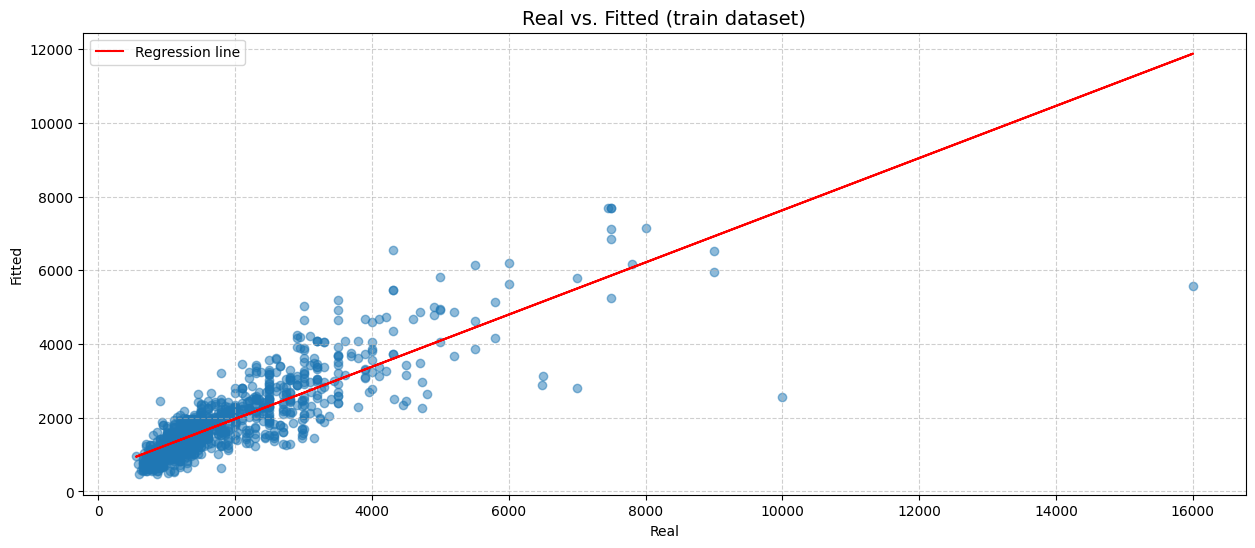

In [160]:
X_train_final_const = sm.add_constant(X_final_c0)
y_pred_c0 = final_model.predict(X_train_final_const)
pred_chart(y_pred_c0, y_train_c0)

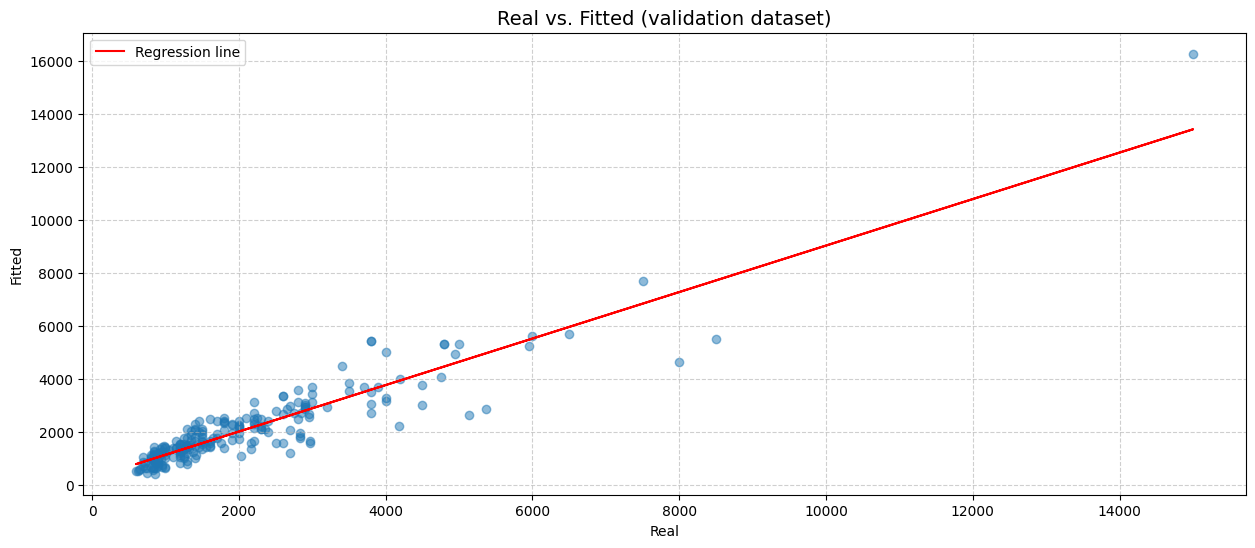

In [161]:
X_val_final_const = sm.add_constant(X_val_c0[X_final_c0.columns])
y_predval = final_model.predict(X_val_final_const)
pred_chart(y_predval, y_val_c0, "validation")

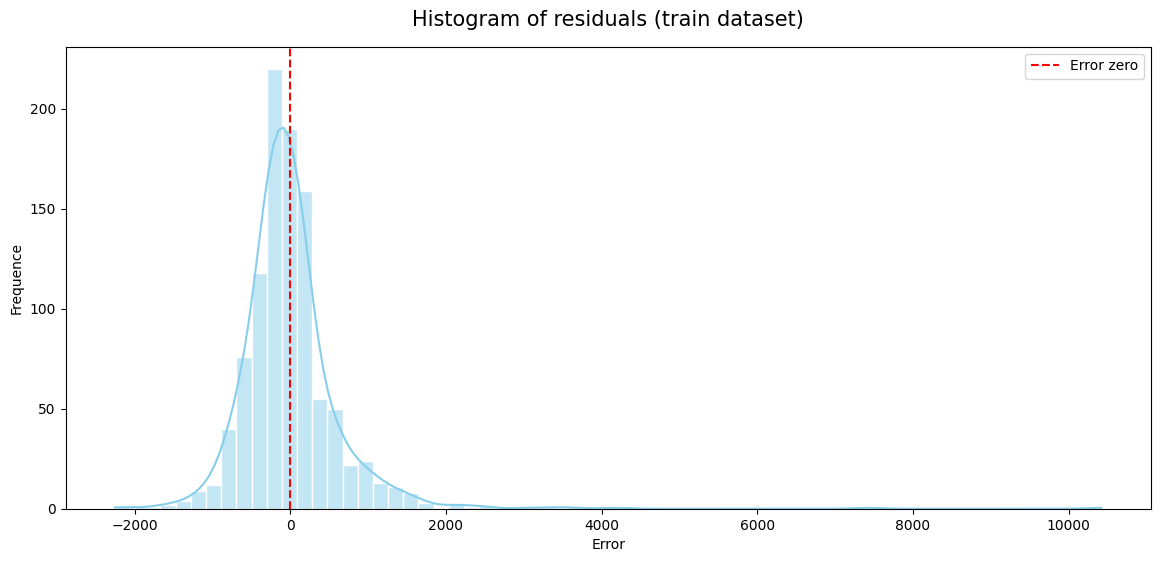

In [162]:
def Hist_resid(y, y_pred, dataset="train"):
    errors = y - y_pred
    plt.figure(figsize=(14, 6))
    sns.histplot(errors, kde=True, color="skyblue", edgecolor="white")
    plt.title(f"Histogram of residuals ({dataset} dataset)", fontsize=15, pad=15)
    plt.xlabel("Error")
    plt.ylabel("Frequence")
    plt.axvline(x=0, color='red', linestyle='--', label='Error zero')
    plt.legend()
    plt.show()

Hist_resid(y_train_c0, y_pred_c0)

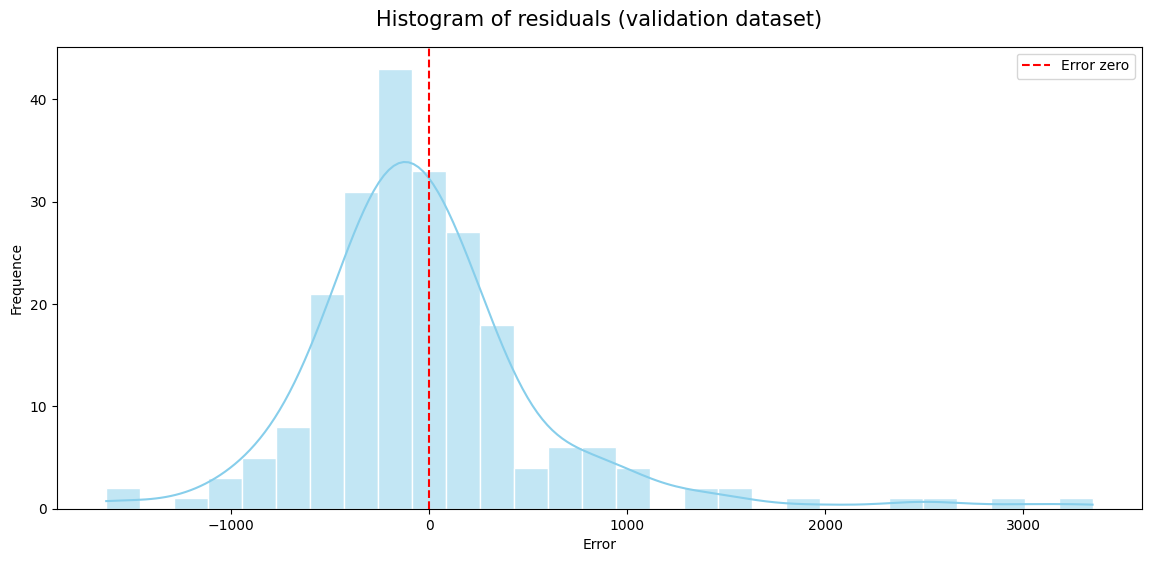

In [163]:
Hist_resid(y_val_c0, y_predval, "validation")

In [164]:
# error comparison between the two datasets
results = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE %'],
    'Train': [
        metrics.mean_absolute_error(y_train_c0, y_pred_c0),
        metrics.mean_squared_error(y_train_c0, y_pred_c0),
        np.sqrt(metrics.mean_squared_error(y_train_c0, y_pred_c0)),
        np.mean(100 * abs(y_train_c0 - y_pred_c0) / y_train_c0)
    ],
    'Test': [
        metrics.mean_absolute_error(y_val_c0, y_predval),
        metrics.mean_squared_error(y_val_c0, y_predval),
        np.sqrt(metrics.mean_squared_error(y_val_c0, y_predval)),
        np.mean(100 * abs(y_val_c0 - y_predval) / y_val_c0)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Metric,Train,Test
0,MAE,408.423843,415.874233
1,MSE,488037.193026,399906.378463
2,RMSE,698.596588,632.381513
3,MAPE %,22.054410,21.210938


Model Adjustment:

C:\Users\ricar\AppData\Local\Temp\ipykernel_9444\3936326457.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


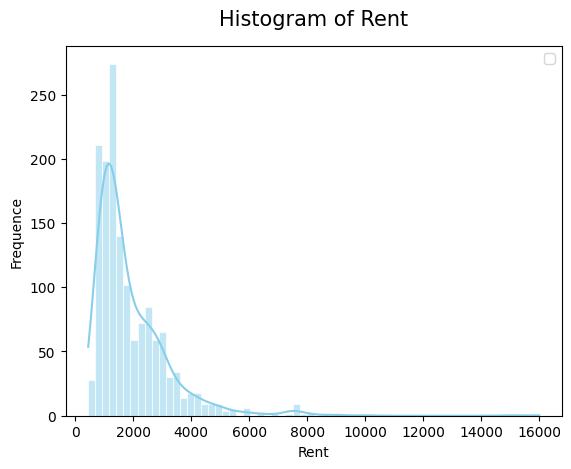

In [165]:
sns.histplot(r_df_c0['Rent'], kde=True, color="skyblue", edgecolor="white")
plt.title(f"Histogram of Rent", fontsize=15, pad=15)
plt.xlabel("Rent")
plt.ylabel("Frequence")
plt.legend()
plt.show()



Highly Skwed Rent Variable, it may be necessary to consder the log(rent) to better handle the ouliers

C:\Users\ricar\AppData\Local\Temp\ipykernel_9444\321603339.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


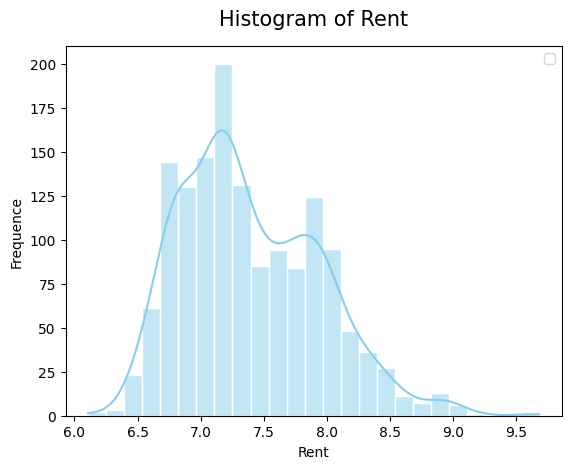

In [166]:
r_df_c0['log_Rent'] =np.log(r_df_c0['Rent'])
sns.histplot(r_df_c0['log_Rent'], kde=True, color="skyblue", edgecolor="white")
plt.title(f"Histogram of Rent", fontsize=15, pad=15)
plt.xlabel("Rent")
plt.ylabel("Frequence")
plt.legend()
plt.show()

In [167]:
X.head()

,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached,District_Barajas,...,District_Moncloa,District_Moratalaz,District_Puente Vallecas,District_Retiro,District_Salamanca,District_San Blás,District_Tetuán,District_Usera,District_Vicálvaro,District_Villa de Vallecas
0,2,72,3,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5,260,2,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,100,3,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,120,4,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1,60,3,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


c:\Users\ricar\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Removing 'District_Hortaleza' with p-value: 0.9372
Removing 'Duplex' with p-value: 0.8732
Removing 'District_Ciudad Lineal' with p-value: 0.8394
Removing 'District_Tetuán' with p-value: 0.7194
Removing 'District_Barajas' with p-value: 0.1903
Removing 'District_Fuencarral' with p-value: 0.0581
Removing 'District_Moratalaz' with p-value: 0.0549


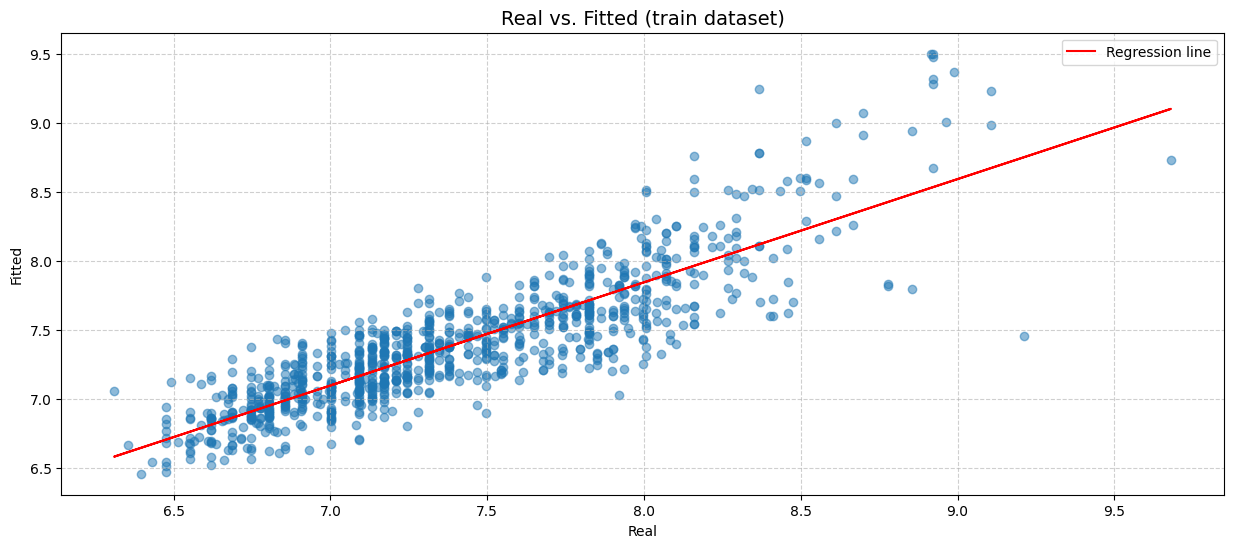

In [168]:
# Separate features and target
X = r_df_c0.drop(columns=["Rent",'Cluster','log_Rent'])
y = r_df_c0["log_Rent"]
# 70% train, 30% validation and test
X_train_c0, X_vt_c0, y_train_c0, y_vt_c0 = train_test_split(
X, y, test_size=0.30, random_state=42)
# Split temp into 15% val, 15% test
X_val_c0, X_test_c0, y_val_c0, y_test_c0 = train_test_split(X_vt_c0, y_vt_c0, test_size=0.50, random_state=42)

X_aftervif_c0 = remove_vif(X_train_c0, thresh=50.0)

base_model = LinearRegression()

rfecv = RFECV( # RFE implemented with cross validation (RFECV)
    estimator=base_model, 
    step=1, # step=1 means it removes one variable in each iteration
    cv=RepeatedKFold(n_splits=5, n_repeats=3),
    scoring='neg_mean_squared_error'
)
rfecv.fit(X_aftervif_c0, y_train_c0)
final_model, final_features = backward_elimination(X_aftervif_c0.loc[:, rfecv.support_], y_train_c0)
X_final_c0 = X_aftervif_c0.loc[:, final_features]
X_train_final_const = sm.add_constant(X_final_c0)
y_pred_c0 = final_model.predict(X_train_final_const)
pred_chart(y_pred_c0, y_train_c0)


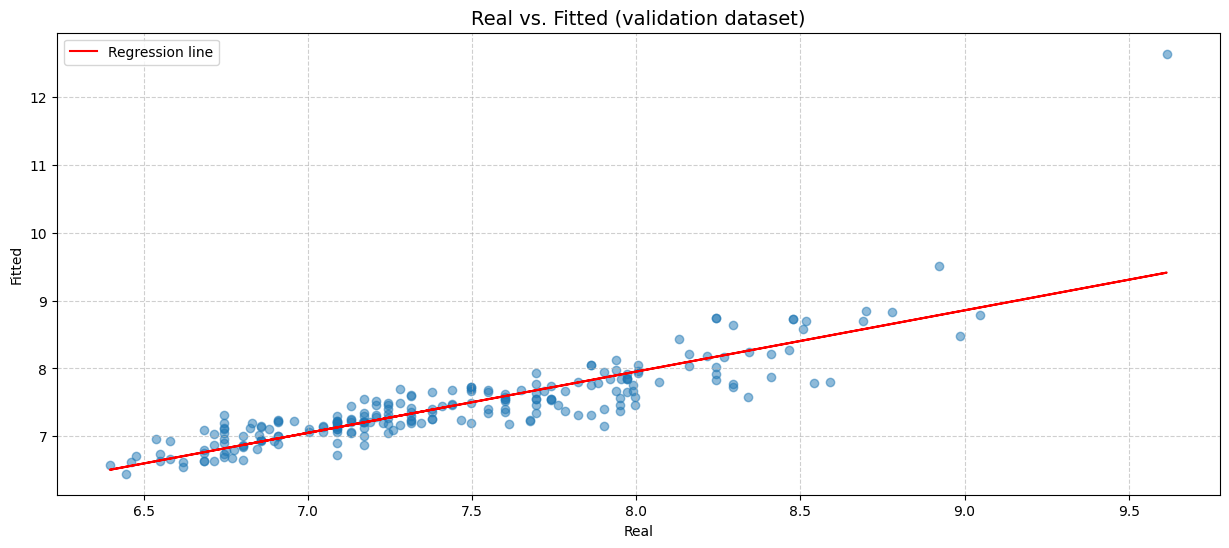

In [169]:
X_val_final_const = sm.add_constant(X_val_c0[X_final_c0.columns])
y_predval = final_model.predict(X_val_final_const)
pred_chart(y_predval, y_val_c0, "validation")

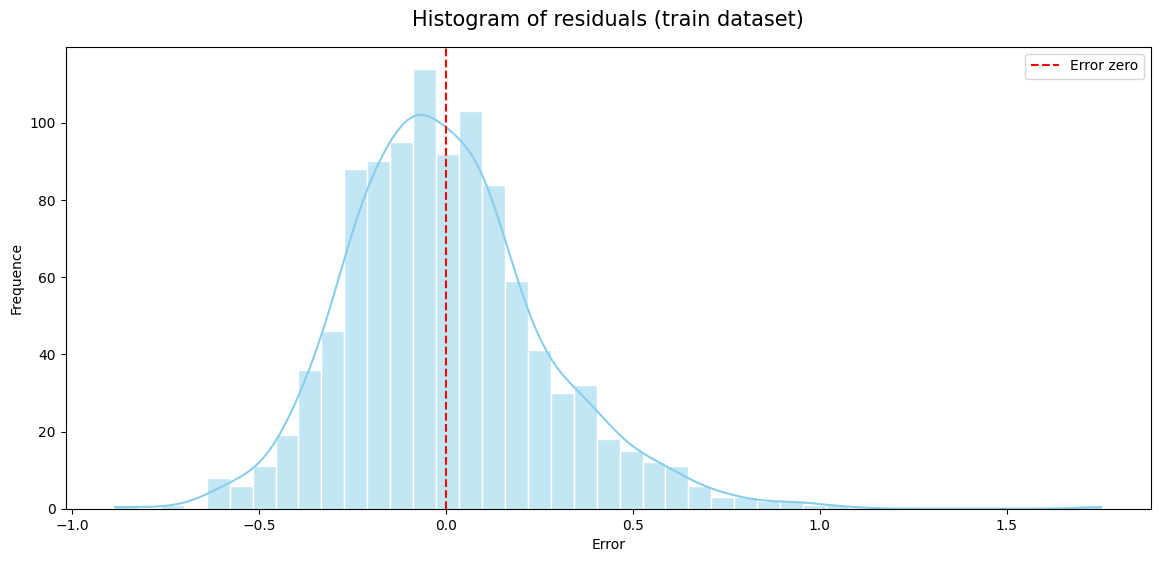

In [170]:
Hist_resid(y_train_c0, y_pred_c0)

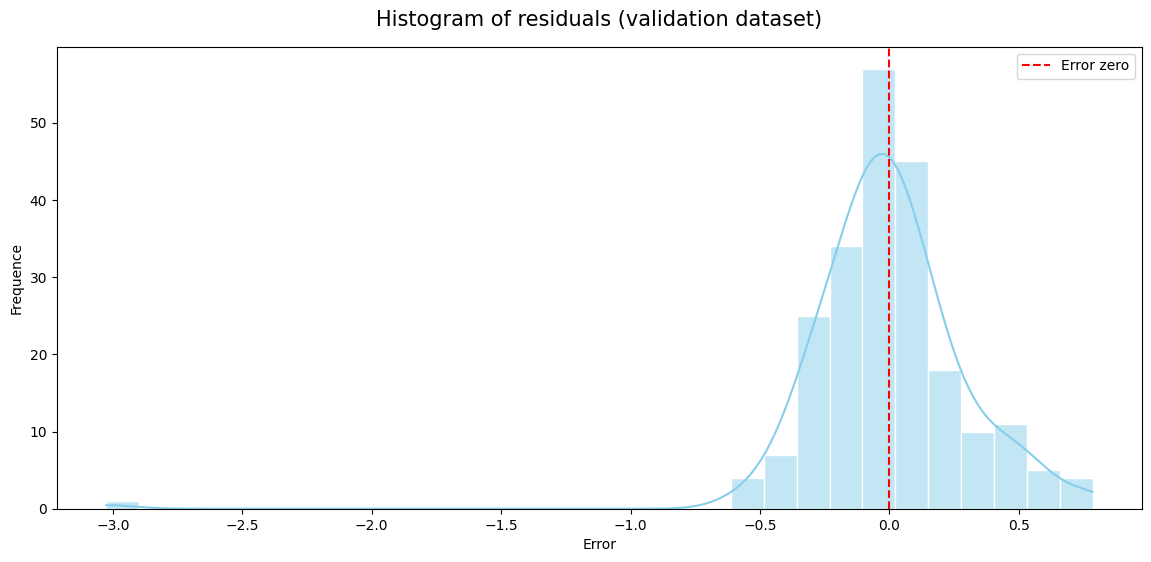

In [171]:
Hist_resid(y_val_c0, y_predval, "validation")

In [172]:
y_train_pred_level = np.exp(y_pred_c0)
y_train_level = np.exp(y_train_c0)

y_val_pred_level = np.exp(y_predval)
y_val_level = np.exp(y_val_c0)
results = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE %'],
    'Train': [
        metrics.mean_absolute_error(y_train_level, y_train_pred_level),
        metrics.mean_squared_error(y_train_level, y_train_pred_level),
        np.sqrt(metrics.mean_squared_error(y_train_level, y_train_pred_level)),
        np.mean(100 * abs(y_train_level - y_train_pred_level) / y_train_pred_level)
    ],
    'Validation': [
        metrics.mean_absolute_error(y_val_level, y_val_pred_level),
        metrics.mean_squared_error(y_val_level, y_val_pred_level),
        np.sqrt(metrics.mean_squared_error(y_val_level, y_val_pred_level)),
        np.mean(100 * abs(y_val_level - y_val_pred_level) / y_val_level)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Metric,Train,Validation
0,MAE,432.020629,1.769303e+03
1,MSE,695699.262876,3.921967e+08
2,RMSE,834.085885,1.980396e+04
3,MAPE %,21.851615,2.782060e+01


In [173]:
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_Rent   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     177.7
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          1.71e-289
Time:                        16:03:37   Log-Likelihood:                -107.63
No. Observations:                1031   AIC:                             251.3
Df Residuals:                    1013   BIC:                             340.2
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

Test:

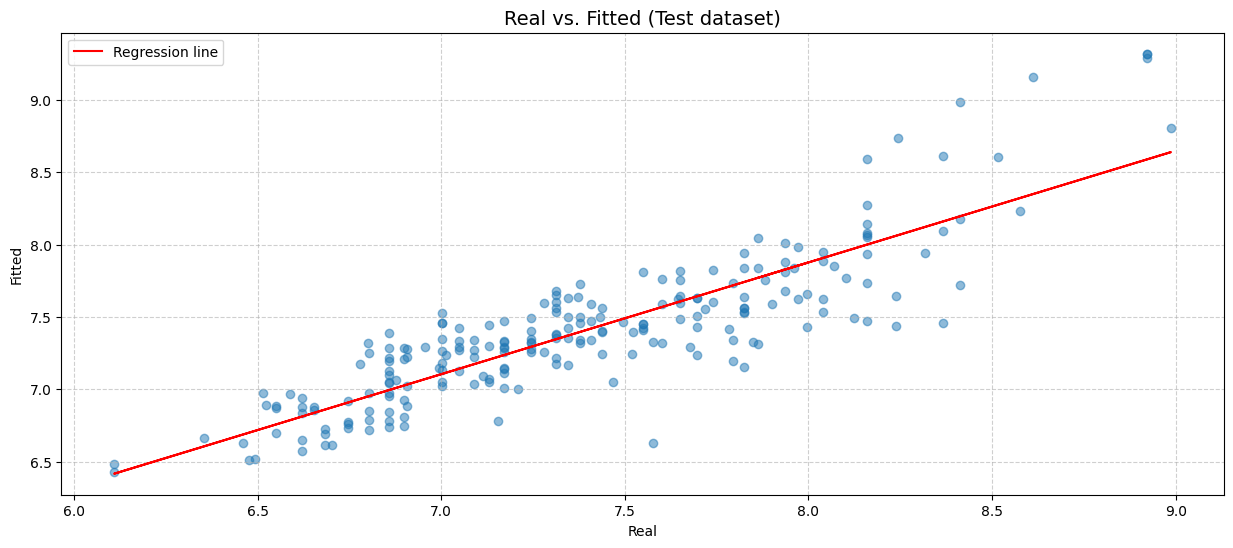

In [174]:
X_test_final_const = sm.add_constant(X_test_c0[X_final_c0.columns])
y_predtest = final_model.predict(X_test_final_const)
pred_chart(y_predtest, y_test_c0, "Test")

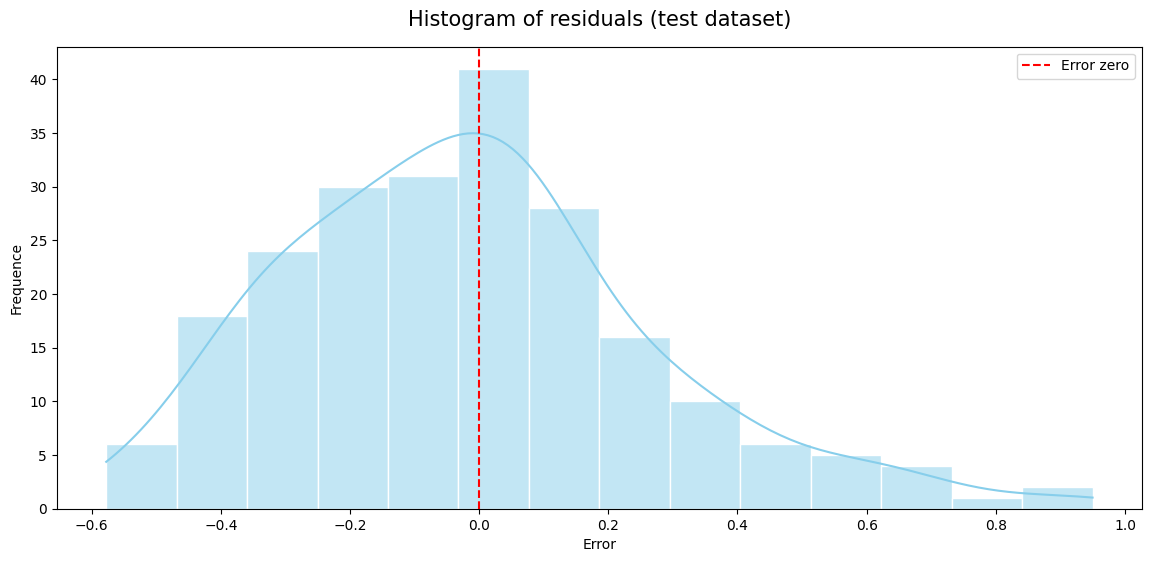

In [175]:
Hist_resid(y_test_c0, y_predtest, "test")

In [176]:
y_train_pred_level = np.exp(y_pred_c0)
y_train_level = np.exp(y_train_c0)

y_val_pred_level = np.exp(y_predval)
y_val_level = np.exp(y_val_c0)

y_test_pred_level = np.exp(y_predtest)
y_test_level = np.exp(y_test_c0)

results = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE %'],
    'Train': [
        metrics.mean_absolute_error(y_train_level, y_train_pred_level),
        metrics.mean_squared_error(y_train_level, y_train_pred_level),
        np.sqrt(metrics.mean_squared_error(y_train_level, y_train_pred_level)),
        np.mean(100 * abs(y_train_level - y_train_pred_level) / y_train_pred_level)
    ],
    'Validation': [
        metrics.mean_absolute_error(y_val_level, y_val_pred_level),
        metrics.mean_squared_error(y_val_level, y_val_pred_level),
        np.sqrt(metrics.mean_squared_error(y_val_level, y_val_pred_level)),
        np.mean(100 * abs(y_val_level - y_val_pred_level) / y_val_level)
    ],
    'Test': [
        metrics.mean_absolute_error(y_test_level, y_test_pred_level),
        metrics.mean_squared_error(y_test_level, y_test_pred_level),
        np.sqrt(metrics.mean_squared_error(y_test_level, y_test_pred_level)),
        np.mean(100 * abs(y_test_level - y_test_pred_level) / y_test_level)
    ]

}

results_df = pd.DataFrame(results)
results_df

,Metric,Train,Validation,Test
0,MAE,432.020629,1.769303e+03,475.836812
1,MSE,695699.262876,3.921967e+08,653709.977813
2,RMSE,834.085885,1.980396e+04,808.523332
3,MAPE %,21.851615,2.782060e+01,22.431796


Regression Cluster 1:

c:\Users\ricar\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


Removing 'District_Chamberí' with p-value: 0.7135
Removing 'Bedrooms' with p-value: 0.7269
Removing 'District_Centro' with p-value: 0.3412
Removing 'Floor' with p-value: 0.3841
Removing 'Semidetached' with p-value: 0.2638
Removing 'Duplex' with p-value: 0.2065
Removing 'District_Chamartín' with p-value: 0.2197
Removing 'Penthouse' with p-value: 0.1307
Removing 'District_Fuencarral' with p-value: 0.1253
Removing 'Outer' with p-value: 0.0738
Removing 'District_Moncloa' with p-value: 0.0938


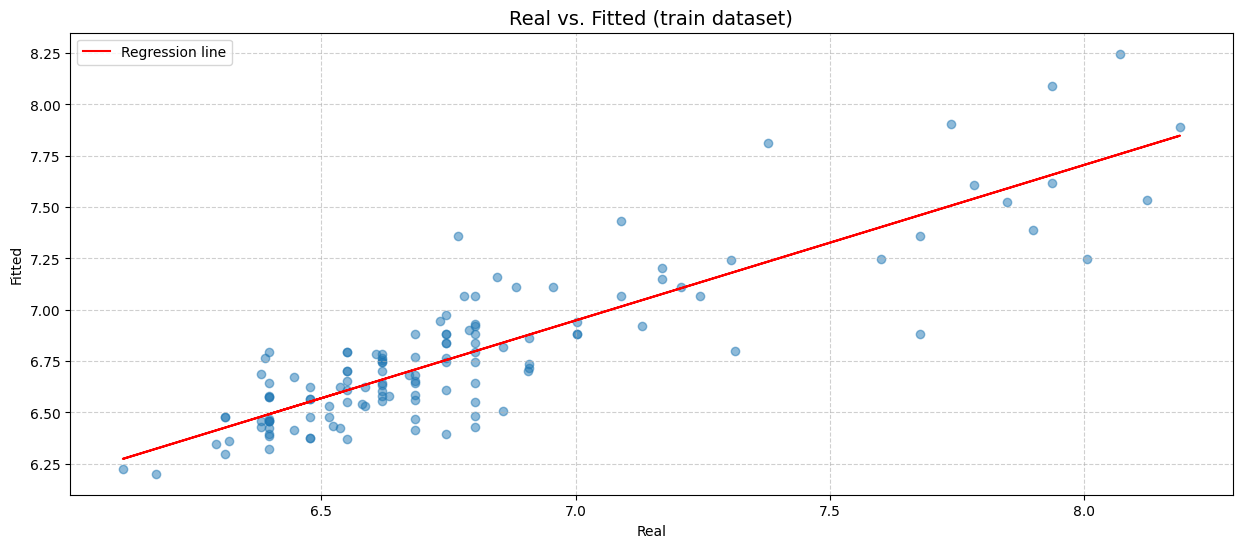

In [177]:
r_df_c1['log_Rent'] =np.log(r_df_c1['Rent'])
X = r_df_c1.drop(columns=["Rent",'Cluster','log_Rent'])
y = r_df_c1["log_Rent"]
# 70% train, 30% validation and test
X_train_c1, X_vt_c1, y_train_c1, y_vt_c1 = train_test_split(
X, y, test_size=0.30, random_state=42)
# Split temp into 15% val, 15% test
X_val_c1, X_test_c1, y_val_c1, y_test_c1 = train_test_split(X_vt_c1, y_vt_c1, test_size=0.50, random_state=42)

X_aftervif_c1 = remove_vif(X_train_c1, thresh=50.0)

base_model = LinearRegression()

rfecv = RFECV( # RFE implemented with cross validation (RFECV)
    estimator=base_model, 
    step=1, # step=1 means it removes one variable in each iteration
    cv=RepeatedKFold(n_splits=5, n_repeats=3),
    scoring='neg_mean_squared_error'
)
rfecv.fit(X_aftervif_c1, y_train_c1)
final_model, final_features = backward_elimination(X_aftervif_c1.loc[:, rfecv.support_], y_train_c1)
X_final_c1 = X_aftervif_c1.loc[:, final_features]
X_train_final_const = sm.add_constant(X_final_c1)
y_pred_c1 = final_model.predict(X_train_final_const)
pred_chart(y_pred_c1, y_train_c1)



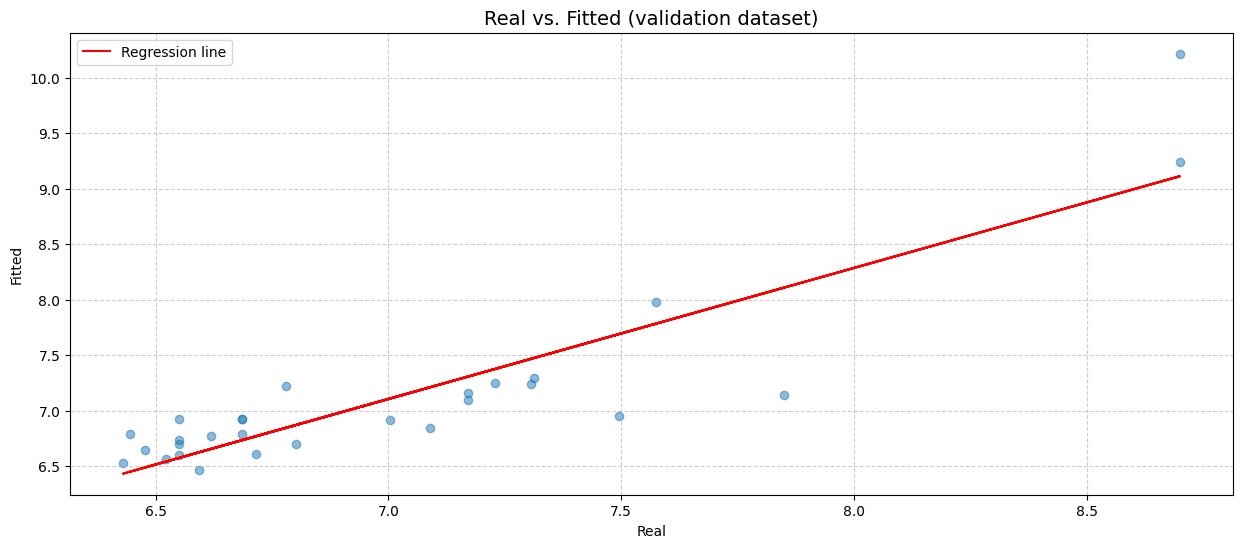

In [178]:
X_val_final_const = sm.add_constant(X_val_c1[X_final_c1.columns])
y_predval = final_model.predict(X_val_final_const)
pred_chart(y_predval, y_val_c1, "validation")


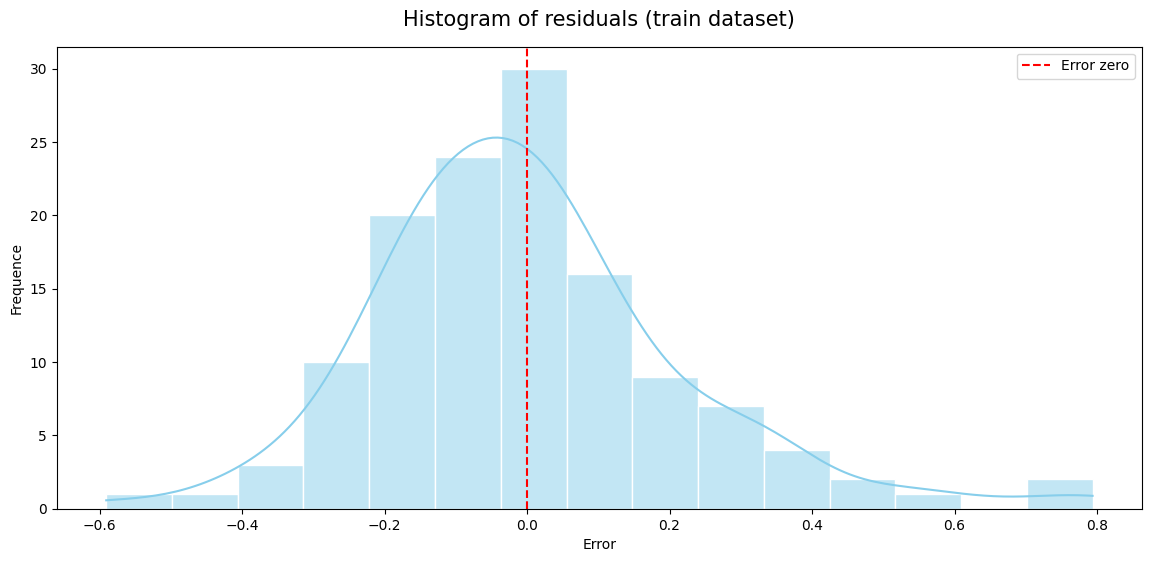

In [179]:
Hist_resid(y_train_c1, y_pred_c1)

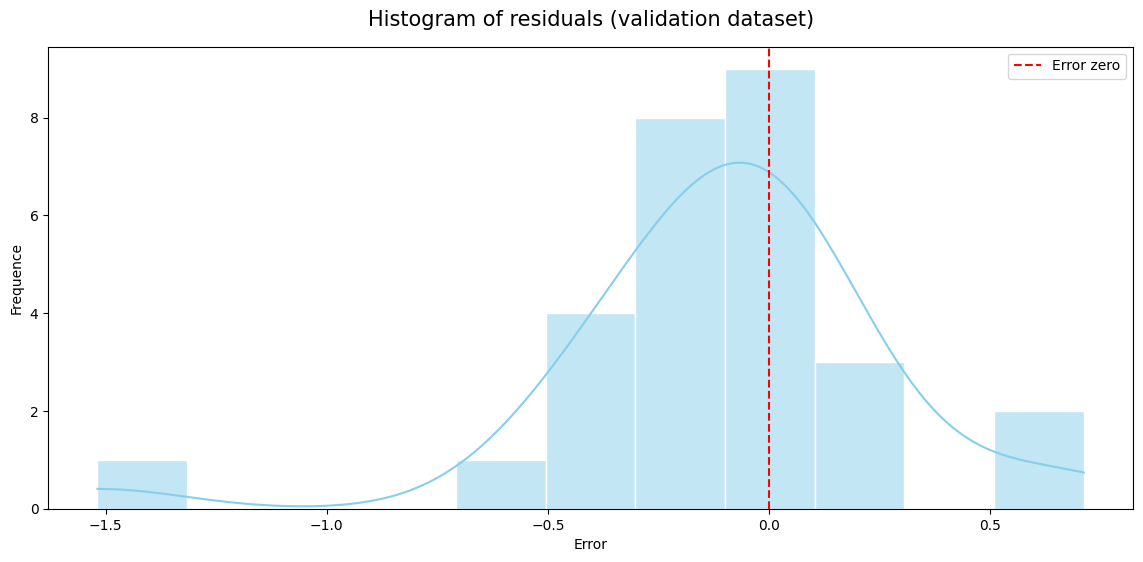

In [180]:
Hist_resid(y_val_c1, y_predval, "validation")

In [181]:
y_train_pred_level = np.exp(y_pred_c1)
y_train_level = np.exp(y_train_c1)

y_val_pred_level = np.exp(y_predval)
y_val_level = np.exp(y_val_c1)
results = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE %'],
    'Train': [
        metrics.mean_absolute_error(y_train_level, y_train_pred_level),
        metrics.mean_squared_error(y_train_level, y_train_pred_level),
        np.sqrt(metrics.mean_squared_error(y_train_level, y_train_pred_level)),
        np.mean(100 * abs(y_train_level - y_train_pred_level) / y_train_pred_level)
    ],
    'Validation': [
        metrics.mean_absolute_error(y_val_level, y_val_pred_level),
        metrics.mean_squared_error(y_val_level, y_val_pred_level),
        np.sqrt(metrics.mean_squared_error(y_val_level, y_val_pred_level)),
        np.mean(100 * abs(y_val_level - y_val_pred_level) / y_val_level)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Metric,Train,Validation
0,MAE,190.572276,1.136614e+03
1,MSE,113086.836586,1.713850e+07
2,RMSE,336.283863,4.139867e+03
3,MAPE %,16.747393,3.399037e+01


In [182]:
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_Rent   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     23.64
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           3.63e-28
Time:                        16:03:40   Log-Likelihood:                 14.547
No. Observations:                 130   AIC:                             2.906
Df Residuals:                     114   BIC:                             48.79
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

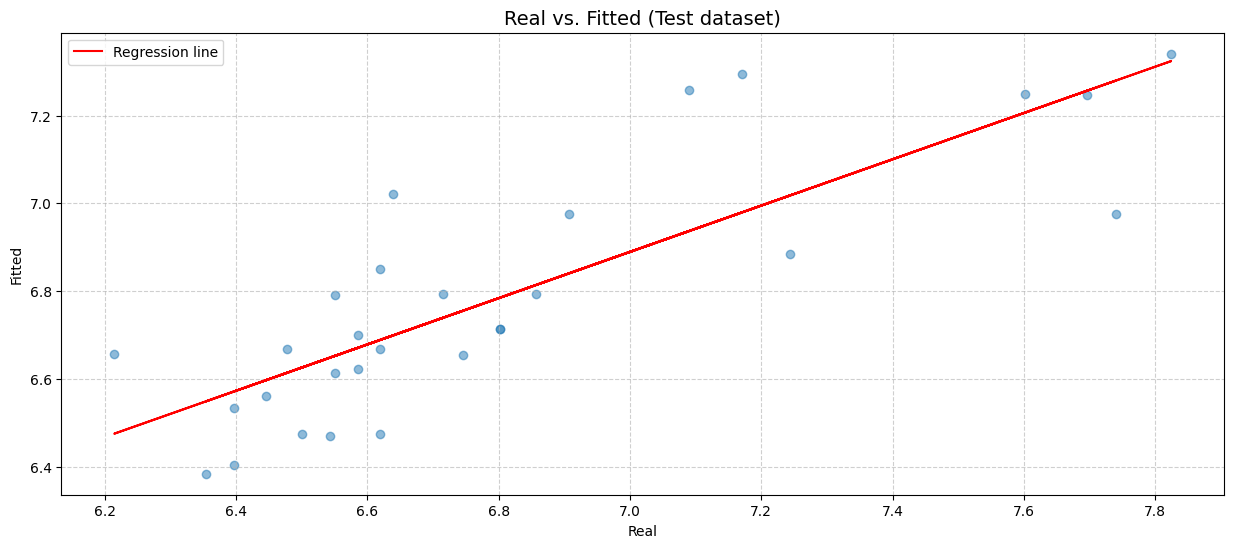

In [183]:
X_test_final_const = sm.add_constant(X_test_c1[X_final_c1.columns])
y_predtest = final_model.predict(X_test_final_const)
pred_chart(y_predtest, y_test_c1, "Test")

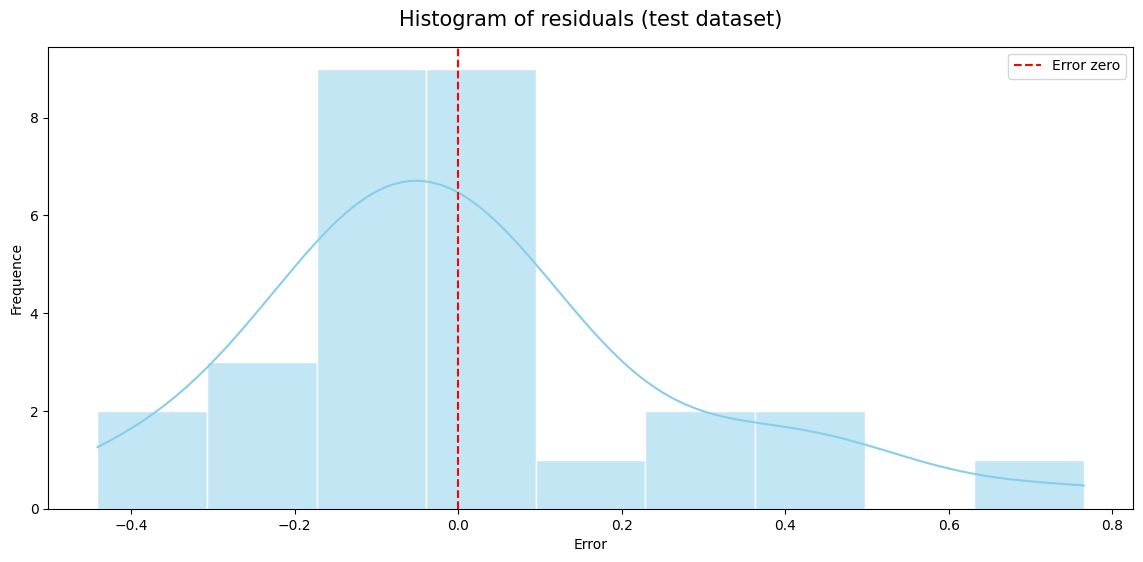

In [184]:
Hist_resid(y_test_c1, y_predtest, "test")

In [185]:
y_train_pred_level = np.exp(y_pred_c1)
y_train_level = np.exp(y_train_c1)

y_val_pred_level = np.exp(y_predval)
y_val_level = np.exp(y_val_c1)

y_test_pred_level = np.exp(y_predtest)
y_test_level = np.exp(y_test_c1)

results = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE %'],
    'Train': [
        metrics.mean_absolute_error(y_train_level, y_train_pred_level),
        metrics.mean_squared_error(y_train_level, y_train_pred_level),
        np.sqrt(metrics.mean_squared_error(y_train_level, y_train_pred_level)),
        np.mean(100 * abs(y_train_level - y_train_pred_level) / y_train_pred_level)
    ],
    'Validation': [
        metrics.mean_absolute_error(y_val_level, y_val_pred_level),
        metrics.mean_squared_error(y_val_level, y_val_pred_level),
        np.sqrt(metrics.mean_squared_error(y_val_level, y_val_pred_level)),
        np.mean(100 * abs(y_val_level - y_val_pred_level) / y_val_level)
    ],
    'Test': [
        metrics.mean_absolute_error(y_test_level, y_test_pred_level),
        metrics.mean_squared_error(y_test_level, y_test_pred_level),
        np.sqrt(metrics.mean_squared_error(y_test_level, y_test_pred_level)),
        np.mean(100 * abs(y_test_level - y_test_pred_level) / y_test_level)
    ]

}

results_df = pd.DataFrame(results)
results_df

,Metric,Train,Validation,Test
0,MAE,190.572276,1.136614e+03,224.654436
1,MSE,113086.836586,1.713850e+07,139154.034286
2,RMSE,336.283863,4.139867e+03,373.033557
3,MAPE %,16.747393,3.399037e+01,18.029138


Regression Cluster 2:

In [186]:
r_df_c2.shape

(154, 30)

c:\Users\ricar\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\ricar\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


Removing 'Penthouse' with VIF: 129.83
Removing 'Semidetached' with p-value: 0.8714
Removing 'Elevator' with p-value: 0.8696
Removing 'District_Puente Vallecas' with p-value: 0.9677
Removing 'District_Hortaleza' with p-value: 0.7767
Removing 'Duplex' with p-value: 0.8939
Removing 'Bedrooms' with p-value: 0.7764
Removing 'District_Chamberí' with p-value: 0.4180
Removing 'District_Moncloa' with p-value: 0.4095
Removing 'District_Moratalaz' with p-value: 0.9963
Removing 'District_San Blás' with p-value: 0.8037
Removing 'District_Centro' with p-value: 0.3411
Removing 'District_Barajas' with p-value: 0.8086
Removing 'District_Tetuán' with p-value: 0.2018
Removing 'Cottage' with p-value: 0.4961
Removing 'District_Chamartín' with p-value: 0.1366
Removing 'Floor' with p-value: 0.0642


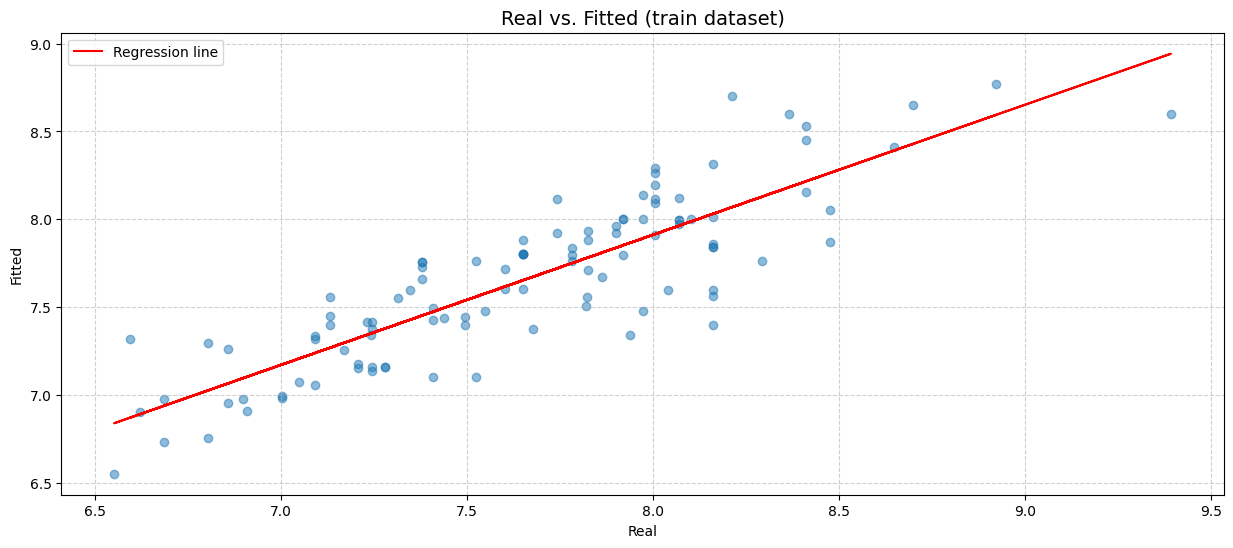

In [187]:
r_df_c2['log_Rent'] =np.log(r_df_c2['Rent'])
X = r_df_c2.drop(columns=["Rent",'Cluster','log_Rent'])
y = r_df_c2["log_Rent"]
# 70% train, 30% validation and test
X_train_c2, X_vt_c2, y_train_c2, y_vt_c2 = train_test_split(
X, y, test_size=0.30, random_state=42)
# Split temp into 15% val, 15% test
X_val_c2, X_test_c2, y_val_c2, y_test_c2 = train_test_split(X_vt_c2, y_vt_c2, test_size=0.50, random_state=42)

X_aftervif_c2 = remove_vif(X_train_c2, thresh=50.0)

base_model = LinearRegression()

rfecv = RFECV( # RFE implemented with cross validation (RFECV)
    estimator=base_model, 
    step=1, # step=1 means it removes one variable in each iteration
    cv=RepeatedKFold(n_splits=5, n_repeats=3),
    scoring='neg_mean_squared_error'
)
rfecv.fit(X_aftervif_c2, y_train_c2)
final_model, final_features = backward_elimination(X_aftervif_c2.loc[:, rfecv.support_], y_train_c2)
X_final_c2 = X_aftervif_c2.loc[:, final_features]
X_train_final_const = sm.add_constant(X_final_c2)
y_pred_c2 = final_model.predict(X_train_final_const)
pred_chart(y_pred_c2, y_train_c2)

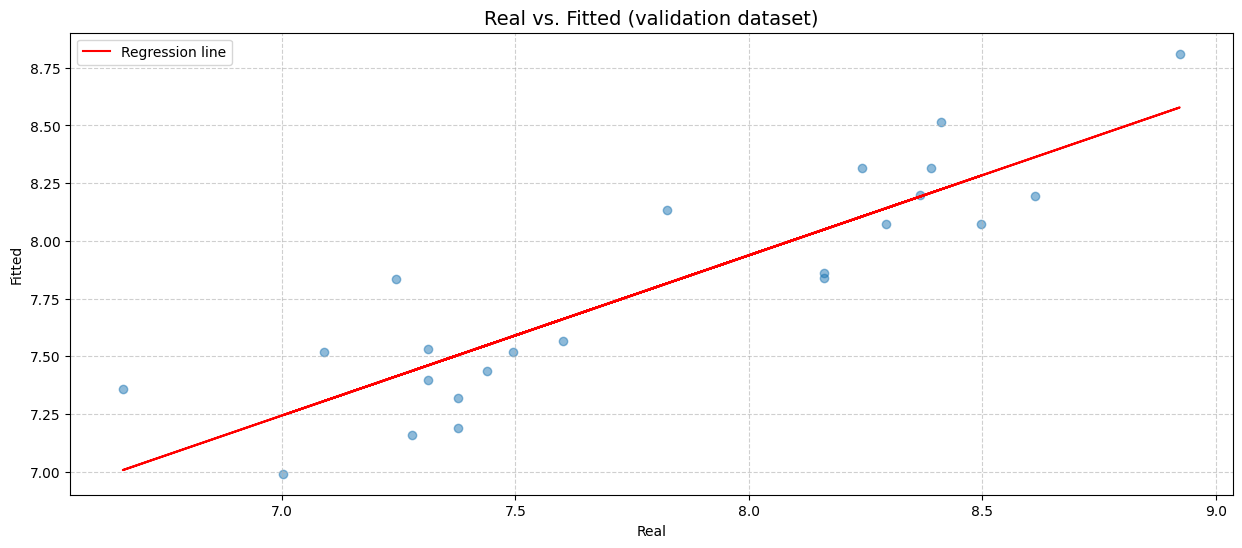

In [188]:
X_val_final_const = sm.add_constant(X_val_c2[X_final_c2.columns])
y_predval = final_model.predict(X_val_final_const)
pred_chart(y_predval, y_val_c2, "validation")

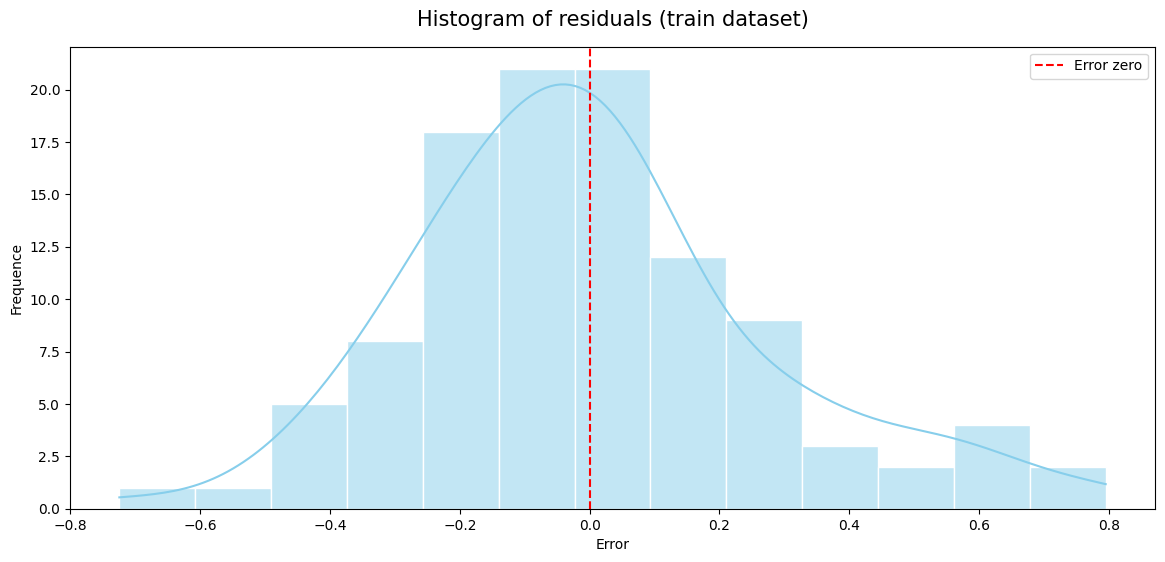

In [189]:
Hist_resid(y_train_c2, y_pred_c2)

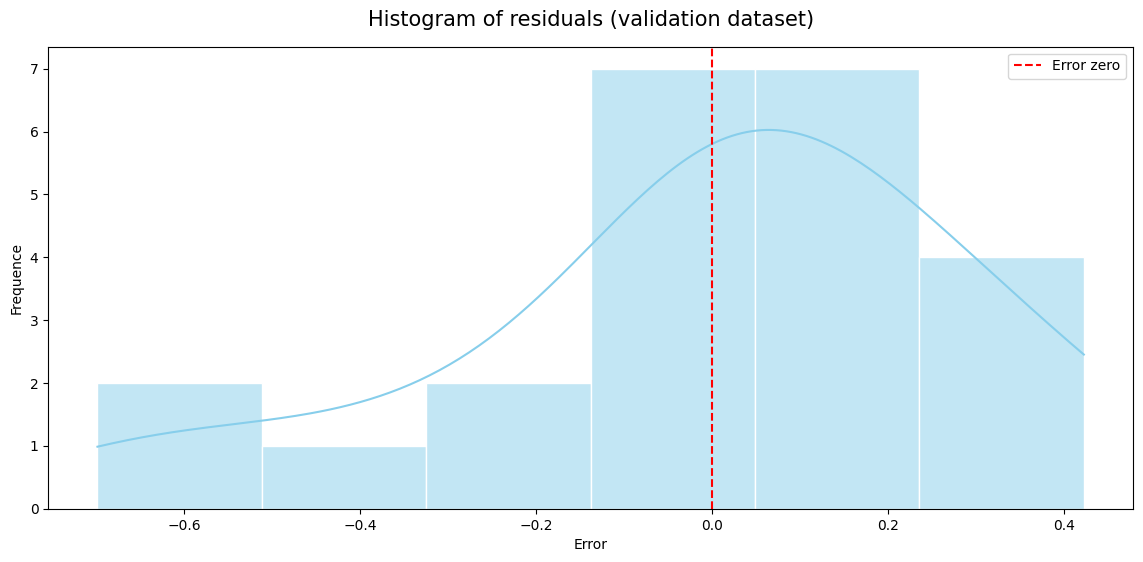

In [190]:
Hist_resid(y_val_c2, y_predval, "validation")

In [191]:
y_train_pred_level = np.exp(y_pred_c2)
y_train_level = np.exp(y_train_c2)

y_val_pred_level = np.exp(y_predval)
y_val_level = np.exp(y_val_c2)
results = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE %'],
    'Train': [
        metrics.mean_absolute_error(y_train_level, y_train_pred_level),
        metrics.mean_squared_error(y_train_level, y_train_pred_level),
        np.sqrt(metrics.mean_squared_error(y_train_level, y_train_pred_level)),
        np.mean(100 * abs(y_train_level - y_train_pred_level) / y_train_pred_level)
    ],
    'Validation': [
        metrics.mean_absolute_error(y_val_level, y_val_pred_level),
        metrics.mean_squared_error(y_val_level, y_val_pred_level),
        np.sqrt(metrics.mean_squared_error(y_val_level, y_val_pred_level)),
        np.mean(100 * abs(y_val_level - y_val_pred_level) / y_val_level)
    ]
}

results_df = pd.DataFrame(results)
results_df

,Metric,Train,Validation
0,MAE,537.875177,581.903211
1,MSE,863581.621699,592784.423008
2,RMSE,929.290924,769.924946
3,MAPE %,21.883911,23.436116


In [192]:
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_Rent   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     27.39
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           6.34e-24
Time:                        16:03:44   Log-Likelihood:                -12.926
No. Observations:                 107   AIC:                             47.85
Df Residuals:                      96   BIC:                             77.25
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

c:\Users\ricar\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


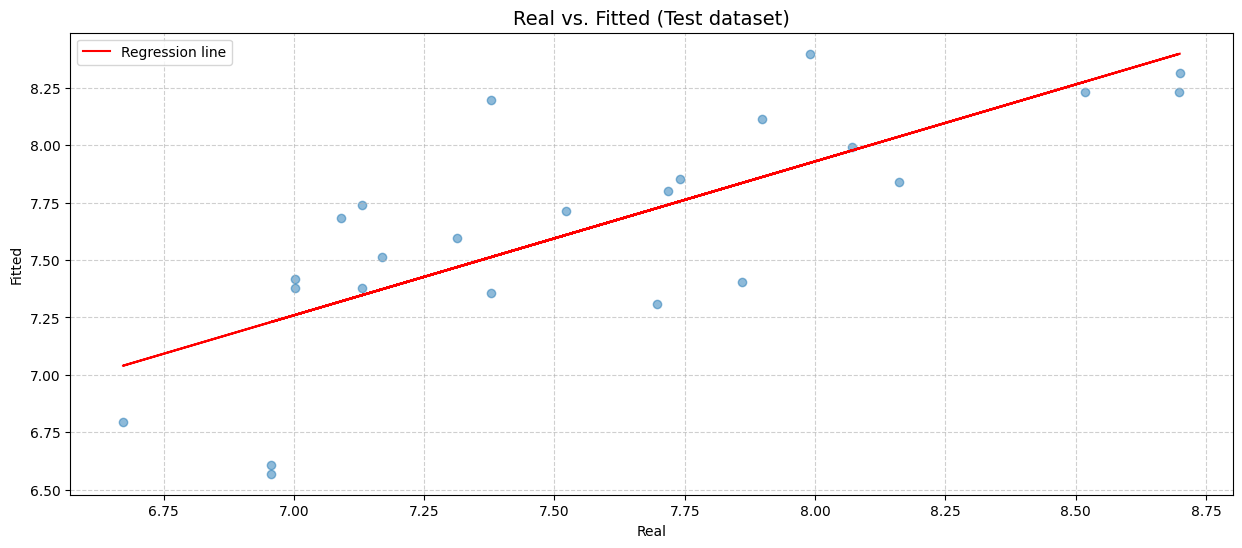

In [204]:
X_test_final_const = sm.add_constant(X_test_c2[X_final_c2.columns], has_constant='add')
y_predtest = final_model.predict(X_test_final_const)
pred_chart(y_predtest, y_test_c2, "Test")

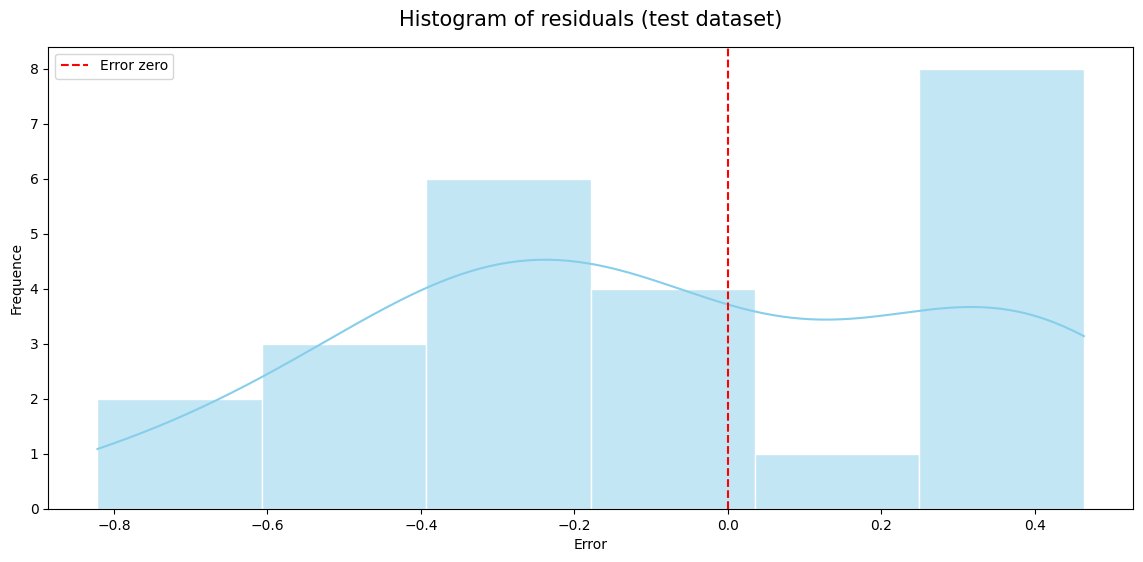

In [205]:
Hist_resid(y_test_c2, y_predtest, "test")

In [206]:
y_train_pred_level = np.exp(y_pred_c2)
y_train_level = np.exp(y_train_c2)

y_val_pred_level = np.exp(y_predval)
y_val_level = np.exp(y_val_c2)

y_test_pred_level = np.exp(y_predtest)
y_test_level = np.exp(y_test_c2)

results = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'MAPE %'],
    'Train': [
        metrics.mean_absolute_error(y_train_level, y_train_pred_level),
        metrics.mean_squared_error(y_train_level, y_train_pred_level),
        np.sqrt(metrics.mean_squared_error(y_train_level, y_train_pred_level)),
        np.mean(100 * abs(y_train_level - y_train_pred_level) / y_train_pred_level)
    ],
    'Validation': [
        metrics.mean_absolute_error(y_val_level, y_val_pred_level),
        metrics.mean_squared_error(y_val_level, y_val_pred_level),
        np.sqrt(metrics.mean_squared_error(y_val_level, y_val_pred_level)),
        np.mean(100 * abs(y_val_level - y_val_pred_level) / y_val_level)
    ],
    'Test': [
        metrics.mean_absolute_error(y_test_level, y_test_pred_level),
        metrics.mean_squared_error(y_test_level, y_test_pred_level),
        np.sqrt(metrics.mean_squared_error(y_test_level, y_test_pred_level)),
        np.mean(100 * abs(y_test_level - y_test_pred_level) / y_test_level)
    ]

}

results_df = pd.DataFrame(results)
results_df

,Metric,Train,Validation,Test
0,MAE,537.875177,581.903211,770.763119
1,MSE,863581.621699,592784.423008,960866.259555
2,RMSE,929.290924,769.924946,980.237859
3,MAPE %,21.883911,23.436116,36.677756
